The objective of this notebook is to illustrate how the classification models can be used 

Let's first import the modules we need:

In [1]:
import pandas as pd
import numpy as np
from decimal import Decimal
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import plotly.graph_objects as go
from pickle import load

We now need to load our data and the classification model. The data presented here came from peat porewater dissolved organic matter (DOM) analysed with a Bruker solariX (–) ESI-FT-ICR-MS system. The formula assignments was conducted using the CoreMS package. The model used in this demo is the polynomial kernel SVM inclusive of PAHs, but the process is the same for the other models.

In [2]:
data_path = 'demo_data.csv'
molecular_formula_column = 'Molecular Formula'
model_path = '../../data/models/poly_svm.pkl'

output_csv_name = 'demo_data--assigned.csv'

outputs_folder = '.'

In [3]:
data_df = pd.read_csv(data_path)
data_df = data_df[~data_df[molecular_formula_column].isna()] # remove peaks with no assigned formula
data_df.fillna(0,inplace=True)
data_df = data_df[data_df[molecular_formula_column]!=0]

In [4]:
with open(model_path, 'rb') as f:
    model = load(f)

Once we load our data, in this specific case we may notice that the formula assignment programme did not include a N/C column. This is easily fixed through pandas.

In [5]:
print(data_df.columns)

Index(['m/z', 'Calibrated m/z', 'Calculated m/z', 'Molecular Formula', 'C',
       'H', 'O', 'S', 'N', '13C', '34S', '18O'],
      dtype='str')


In [6]:
ratios_needed = ['O/C','H/C','N/C']

for ratio in ratios_needed:
    
    if ratio not in data_df.columns:
        
        elements = ratio.split('/')

        denominator = data_df[elements[1]]

        if elements[1] == 'C' and '13C' in data_df.columns:
            denominator += data_df['13C']
        
        data_df[ratio] = data_df[elements[0]] / denominator

In [7]:
vk_region_colours = {
    'lipid': '#F5C308',
    'peptide': '#BD3A53',
    'carbohydrate': '#0040FF',
    'amino_sugar': '#7C9EBF',
    'lignin': '#33251E',
    'tannin': '#CE833B',
    'pah': '#808080',
}

# Create Combined 2D and 3D Van Krevelen Diagram with PAHs
# Side-by-side comparison showing both perspectives

def plot_2d3d(df,colour_list,savepath=None,cmap='RdBu',cbar_title=None,
              xlim=(0, 1.5),ylim=(.1, 2.5),zlim=(0, .35)):

  fig = plt.figure(figsize=(13, 6),layout='constrained')

  # 2D Plot (subplot a)
  ax_2d = fig.add_subplot(121)

  if all([not isinstance(x,str) for x in colour_list]):
    comb = np.array([colour_list,colour_list]).flatten()
    norm = Normalize(vmin=np.min(comb),vmax=np.max(comb))

  ax_2d.scatter(df['O/C'], df['H/C'],
                        c=colour_list,
                        cmap = None if any([isinstance(x,str) for x in colour_list]) else cmap,
                        norm = None if any([isinstance(x,str) for x in colour_list]) else norm,
                        lw=.1,edgecolors='k',
                        s=10)

  ax_2d.set_xlabel('O/C', fontsize=14)
  ax_2d.set_ylabel('H/C', fontsize=14)

  # 3D Plot (subplot b)
  ax_3d = fig.add_subplot(122, projection='3d')

  map3d = ax_3d.scatter(df['O/C'], df['H/C'], df['N/C'],
                c=colour_list,
                cmap = None if any([isinstance(x,str) for x in colour_list]) else cmap,
                norm = None if any([isinstance(x,str) for x in colour_list]) else norm,
                lw=.2,edgecolors='k',
                s=10)

  ax_3d.view_init(elev=15, azim=-60)

  ax_3d.set_xlabel('O/C', fontsize=14, labelpad=15)
  ax_3d.set_ylabel('H/C', fontsize=14, labelpad=15)
  ax_3d.set_zlabel('N/C', fontsize=14, labelpad=8)

  ax_3d.set_box_aspect(None, zoom=1.15)

  # Add subplot labels
  ax_2d.set_title('(a)', fontsize=20)
  ax_3d.set_title('(b)', fontsize=20)

  # colourbar
  if all([not isinstance(x,str) for x in colour_list]):
    middle_value = (np.min(comb)+np.max(comb)) / 2
    above_middle = (np.max(comb)+middle_value)/2
    below_middle = (np.min(comb)+middle_value)/2
    cbar_ticks = [np.min(comb),below_middle,middle_value,above_middle,np.max(comb)]

    cax = ax_3d.inset_axes([1.25, 0.0, 0.05, 1.025])
    cbar = fig.colorbar(map3d, cax=cax,ax=[ax_2d, ax_3d],
                        ticks=cbar_ticks,)
    
    cbar.set_label(cbar_title,fontsize=14)

  if savepath is not None:
    fig.savefig(savepath, dpi=400, facecolor='#fff', bbox_inches='tight')

  return fig, ax_2d, ax_3d

def draw_violinplot(data_dict, ylabel, title=None, savepath=None, colours=[],alpha=1,
                    hline=None, xlabel_rotation=45, ha='right', figsize=(6.4, 4.8)):
    '''
    Create a violin plot to visualize the distribution of data.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary where keys are labels and values are data arrays
    ylabel : str
        Y-axis label
    title : str, optional
        Plot title
    savepath : str, optional
        Path to save the figure
    colours : list, optional
        Colors for each violin plot
    hline : float or list, optional
        Horizontal reference line(s) to draw
    xlabel_rotation : int
        Rotation angle for x-axis labels
    ha : str
        Horizontal alignment for x-axis labels
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    '''
    labels = list(data_dict.keys())
    data = list(data_dict.values())

    fig, ax = plt.subplots(figsize=figsize)

    # Create violin plots without default decorations
    parts = ax.violinplot(data,
                          showmeans=False, showmedians=False,
                          showextrema=False)

    # Apply custom colors to violin plots
    if len(colours) > 0:
        if len(colours) == 1:
            colours = colours * len(labels)
        assert len(colours) == len(labels), "Number of colours must match number of violin plots"
        for pc, c in zip(parts['bodies'], colours):
            pc.set_facecolor(c)
            pc.set_edgecolor('black')
            pc.set_alpha(alpha)

    # Calculate and display quartiles
    for i in range(len(labels)):
        quartile1, medians, quartile3 = np.percentile(np.array(data[i]), [25, 50, 75])

        ax.scatter(i+1, medians, marker='o', color='white', s=30, zorder=3, edgecolors='k')
        ax.vlines(i+1, quartile1, quartile3, color='k', linestyle='-', lw=5)

    # Format axes
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(np.arange(1, len(labels) + 1), labels, rotation=xlabel_rotation, ha=ha, fontsize=12)
    
    # Add horizontal reference lines if specified
    if hline:
        if type(hline) in [list, tuple]:
            for hl in hline:
                ax.axhline(y=hl, color='r', linestyle='--', lw=1)
        else:
            ax.axhline(y=hline, color='r', linestyle='--', lw=1)

    if title:
        ax.set_title(title, fontsize=14)
    if savepath:
        fig.savefig(savepath, dpi=600, facecolor='#fff', bbox_inches='tight')

    return fig, ax

Now everything is ready for the classification model to predict compound classes!

In [8]:
predictions = model.predict(data_df[['O/C','H/C','N/C']].values)
data_df['compound_class'] = predictions
predictions

array(['pah', 'lignin', 'lipid', ..., 'tannin', 'lignin', 'carbohydrate'],
      shape=(1954,), dtype=object)

We can visualise how many compounds were assigned to the various compound classes:

Total number of formulas: 1954
Total number of amino sugar-like: 2 (0.1%)
Total number of carbohydrate-like: 15 (0.77%)
Total number of lignin-like: 1065 (54.5%)
Total number of lipid-like: 299 (15.3%)
Total number of PAH-like: 100 (5.12%)
Total number of peptide-like: 5 (0.26%)
Total number of tannin-like: 468 (23.95%)


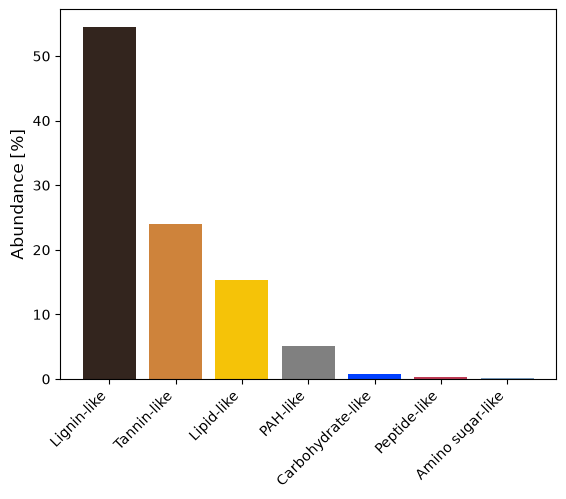

In [9]:
tot_form = len(predictions)
print(f'Total number of formulas: {tot_form}')

labels = []
percs = []

predictions_unique = np.unique(predictions)
for cat in predictions_unique:
    label = cat.replace('_',' ') if cat != 'pah' else 'PAH'
    label += '-like'
    labels.append(label.capitalize() if label != 'PAH-like' else label)

    i = np.where(predictions==cat)[0]
    tot = len(i)
    perc = 100*len(i) / tot_form
    percs.append(perc)
    perc = np.round(perc,2)

    print(f'Total number of {label}: {tot} ({perc}%)')

fig, ax = plt.subplots()

labels = np.array(labels)
percs = np.array(percs)
idxs = np.argsort(percs)[::-1]
c = [vk_region_colours[x] for x in predictions_unique[idxs]]
ax.bar(labels[idxs],percs[idxs], color=c)
ax.set_ylabel('Abundance [%]',fontsize=12)
ax.set_xticks(range(len(labels)),labels[idxs],
              rotation=45,ha='right')

The results can be plotted on a 2D van Krevelen diagram.

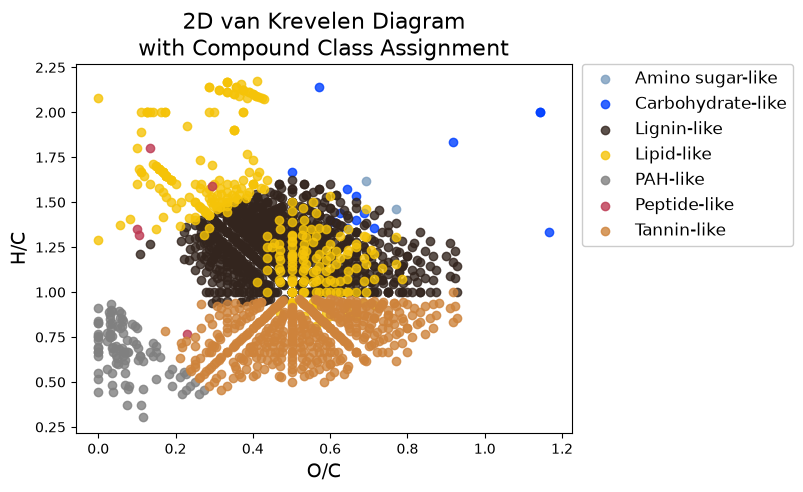

In [10]:
fig, ax = plt.subplots()

for compound_class in np.sort(predictions_unique):

    ax.scatter(data_df[predictions==compound_class]['O/C'],
               data_df[predictions==compound_class]['H/C'],
               c=vk_region_colours[compound_class],
               label=f'{compound_class.replace('_',' ').capitalize()}-like' if 'pah' not in compound_class else 'PAH-like',
               alpha=0.8)

ax.set_xlabel('O/C',fontsize=14)
ax.set_ylabel('H/C',fontsize=14)
ax.set_title('2D van Krevelen Diagram\nwith Compound Class Assignment',fontsize=16)
ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)

A 3D van Krevelen diagram can also be drawn using matplotlib.

The function ```predict_proba``` finds the predicted probability for each class.

In [11]:
predictions_probabilities = model.predict_proba(data_df[['O/C','H/C','N/C']].values)
max_probabilities = 100 * np.max(predictions_probabilities,axis=1)

predictions_probabilities

array([[1.74838616e-23, 2.56211159e-06, 2.47215677e-05, ...,
        9.74081465e-01, 2.87819754e-09, 2.58911482e-02],
       [5.01941808e-16, 3.54299971e-02, 9.57587729e-01, ...,
        5.93416921e-07, 6.17671351e-13, 5.18671726e-08],
       [9.51473413e-09, 8.13663238e-02, 4.87817132e-06, ...,
        6.10907310e-07, 3.42370643e-12, 6.68750720e-10],
       ...,
       [5.74425556e-16, 1.01117560e-03, 6.87041077e-02, ...,
        5.78194495e-07, 4.82985129e-16, 9.30280971e-01],
       [5.14313027e-16, 1.04931236e-03, 9.70573293e-01, ...,
        2.13543726e-06, 5.05826113e-16, 2.83719679e-02],
       [1.58453807e-02, 9.83674047e-01, 4.79858174e-04, ...,
        5.76638727e-07, 5.31969380e-13, 6.02065301e-09]], shape=(1954, 7))

In [12]:
data_df['probability'] = max_probabilities
data_df

,m/z,Calibrated m/z,Calculated m/z,Molecular Formula,C,H,O,S,N,13C,34S,18O,O/C,H/C,N/C,compound_class,probability
0,645.219141,645.218553,645.218366,C45 H30 O3 N2,45.0,30.0,3.0,0.0,2.0,0.0,0.0,0.0,0.066667,0.666667,0.044444,pah,97.408146
1,619.203677,619.203125,619.203229,C30 H36 O14,30.0,36.0,14.0,0.0,0.0,0.0,0.0,0.0,0.466667,1.200000,0.000000,lignin,95.758773
2,617.358234,617.357685,617.357622,C28 H58 O12 S1,28.0,58.0,12.0,1.0,0.0,0.0,0.0,0.0,0.428571,2.071429,0.000000,lipid,91.862818
3,613.541768,613.541223,613.541264,C37 H74 O6,37.0,74.0,6.0,0.0,0.0,0.0,0.0,0.0,0.162162,2.000000,0.000000,lipid,96.185093
4,607.239979,607.239443,607.239615,C30 H40 O13,30.0,40.0,13.0,0.0,0.0,0.0,0.0,0.0,0.433333,1.333333,0.000000,lignin,97.568773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1949,213.076904,213.076827,213.076847,C10 H14 O5,10.0,14.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.400000,0.000000,lignin,94.972955
1950,211.061284,211.061210,211.061197,C10 H12 O5,10.0,12.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.200000,0.000000,lignin,95.757305
1951,211.024872,211.024798,211.024811,C9 H8 O6,9.0,8.0,6.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.888889,0.000000,tannin,93.028097
1952,209.045597,209.045525,209.045547,C10 H10 O5,10.0,10.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.000000,0.000000,lignin,97.057329


The probability of the assigned class can thus be found. Both the assignments and their probabilities can then be added as columns in the dataframe.

The assignment confidence can also be visualised on a van Krevelen diagram.

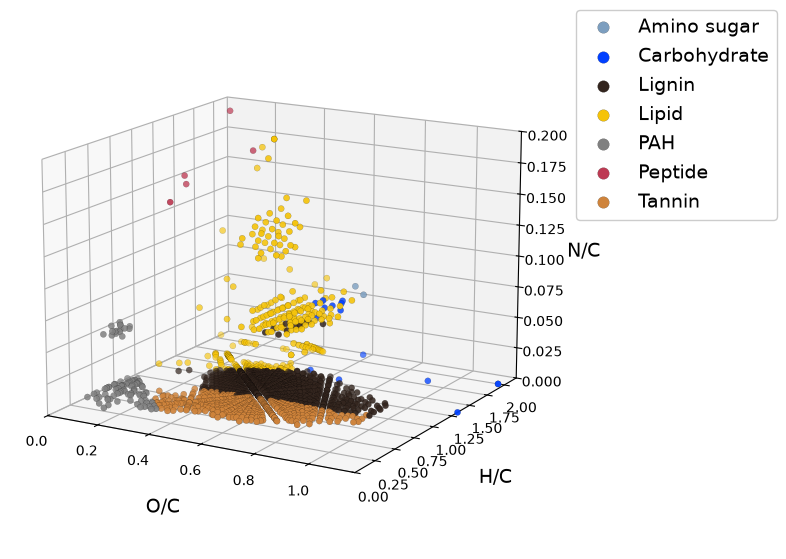

In [13]:
# Create 3D Van Krevelen Diagram with PAHs
# Third dimension (N/C) provides additional chemical space information

fig = plt.figure(figsize=(12, 7))  # width, height

ax = fig.add_subplot(111, projection='3d')

# Plot all data points colored by compound_class
ax.scatter(data_df['O/C'], data_df['H/C'], data_df['N/C'],
           c=[vk_region_colours[cat] for cat in data_df['compound_class']],
           edgecolor='k', lw=.1)

# Create legend
for cat in np.sort(data_df['compound_class'].unique()):
    ax.scatter(10,10,10, c=vk_region_colours[cat], alpha=1, edgecolor='k', lw=.1,
               label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH',
               s=70)

ax.legend(framealpha=1, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=14)
ax.view_init(elev=15, azim=-60)

# Label axes
ax.set_xlabel('O/C', fontsize=14, labelpad=15)
ax.set_ylabel('H/C', fontsize=14, labelpad=15)
ax.set_zlabel('N/C', fontsize=14, labelpad=8)

ax.set_xlim(0,data_df['O/C'].max())
ax.set_ylim(0,data_df['H/C'].max())
ax.set_zlim(0,data_df['N/C'].max())

fig.savefig(f'{outputs_folder}/3d_vK.png', dpi=600, facecolor='#fff', bbox_inches='tight')

Alternatively, the Plotly package can be used to draw 3D diagrams with N/C as an additional axis.

In [14]:
vizList = []
for compound_class in np.sort(data_df['compound_class'].unique()):

    globals()[f'D_{compound_class}']=go.Scatter3d(

        x = data_df[data_df['compound_class'] == compound_class]['O/C'],
        y = data_df[data_df['compound_class'] == compound_class]['H/C'],
        z = data_df[data_df['compound_class'] == compound_class]['N/C'],

        name = f'{compound_class.replace('_',' ').capitalize()}-like' if 'pah' not in compound_class else 'PAH-like',

        hovertemplate = 'O/C: %{x} <br>' + \
                        'H/C: %{y} <br>' + \
                        'N/C: %{z} <br>',

        mode='markers',
        marker=dict(
            size=8,
            color=vk_region_colours[compound_class],           
            opacity=0.8,
            symbol='circle'
        )
    )

    vizList.append(globals()[f'D_{compound_class}']) 

fig = go.Figure(data=vizList)

camera = dict(
        up=dict(x=0, y=0, z=1),
        center=dict(x=0, y=0, z=0),
        eye=dict(x=-1, y=-1.75, z=1.5)
    )

fig.update_layout(
    scene_camera=camera,
    autosize=True,
    template='plotly_white',
    scene={
        'xaxis_title':'O/C',
        'yaxis_title':'H/C',
        'zaxis_title':'N/C'
    },
    width=800, height=600,
    showlegend=True,
    legend_font_size = 14,
    title = '3D van Krevelen Diagram with Compound Class Assignment',
    title_font_size = 20
)

fig.show()

# 3D vK diagrams created with Plotly are saved as HTML files
fig.write_html(f'{outputs_folder}/3d_vK_interactive.html')

One of the strengths of using a supervised classifier for compound class prediction is that we can have a measure of the confidence of the assignment. In the following cell we will visualise how the assignment confidence varies within the dataset and between different compound classes.

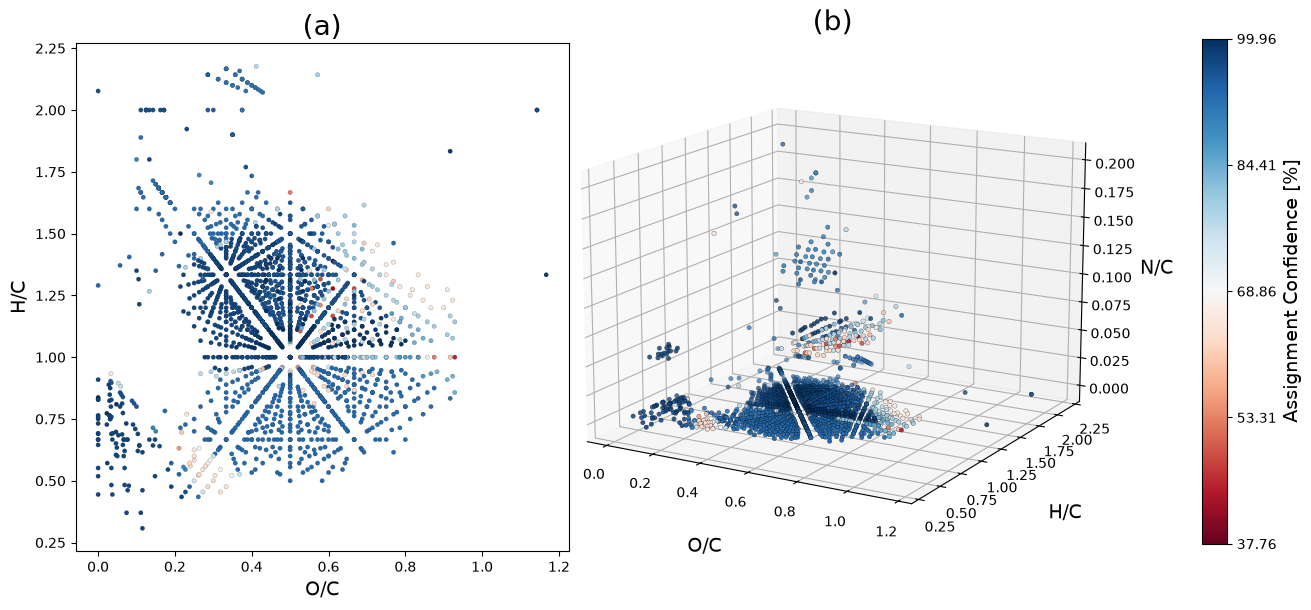

In [15]:
class_colours = [vk_region_colours[x] for x in predictions]

fig, ax_2d, ax_3d = plot_2d3d(data_df,max_probabilities,
                              cbar_title='Assignment Confidence [%]')

(40.0, 100.0)

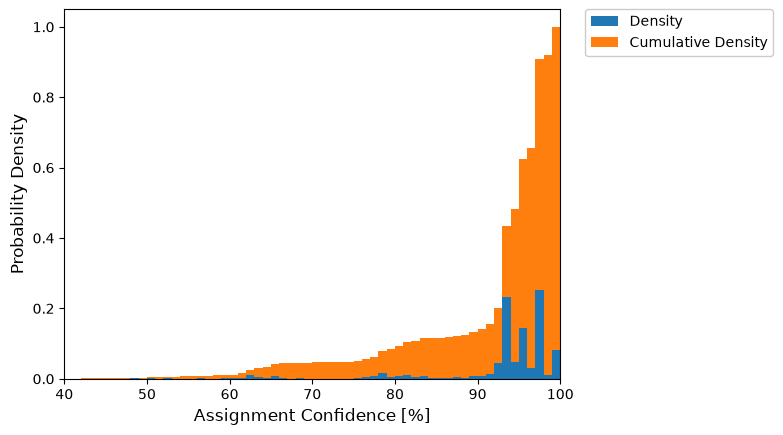

In [16]:
fig, ax = plt.subplots()
limits = np.arange(37,101,1)
n, bins, patches = ax.hist(max_probabilities,bins=limits,density=True,label='Density')
n, bins, patches = ax.hist(max_probabilities,bins=limits,density=True,cumulative=True,zorder=-1,label='Cumulative Density')

ax.legend(framealpha=1,bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

ax.set_xlabel('Assignment Confidence [%]',fontsize=12)
ax.set_ylabel('Probability Density',fontsize=12)

ax.set_xlim(40,100)

Amino sugar-like assignment confidence: 86 ± 7 %
Carbohydrate-like assignment confidence: 80 ± 20 %
Lignin-like assignment confidence: 95 ± 7 %
Lipid-like assignment confidence: 90 ± 10 %
PAH-like assignment confidence: 96 ± 5 %
Peptide-like assignment confidence: 80 ± 20 %
Tannin-like assignment confidence: 91 ± 7 %


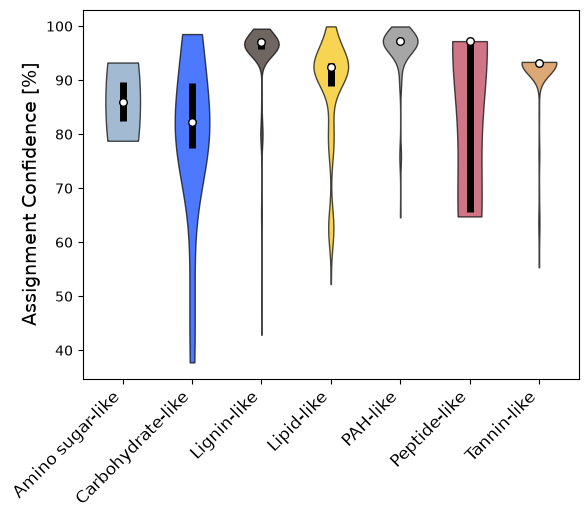

In [17]:
probs = {}
for cat in predictions_unique:
    i = np.where(predictions==cat)[0]

    label = cat.replace('_',' ').capitalize() if cat != 'pah' else 'PAH'
    label += '-like'
    probs[label] = max_probabilities[i]

    avg = np.mean(probs[label])
    std = np.std(probs[label])

    scientific = ('%.0E' % Decimal(std)).split('E')
    dec_places = -int(scientific[1])
    avg = np.round(avg,dec_places)
    std = np.round(std,dec_places)
    if std >= 1:
        avg = int(avg)
        std = int(std)

    print(f'{label} assignment confidence: {avg} ± {std} %')

fig, ax = draw_violinplot(probs,ylabel='Assignment Confidence [%]',
                          colours=[vk_region_colours[y] for y in predictions_unique],alpha=.7)

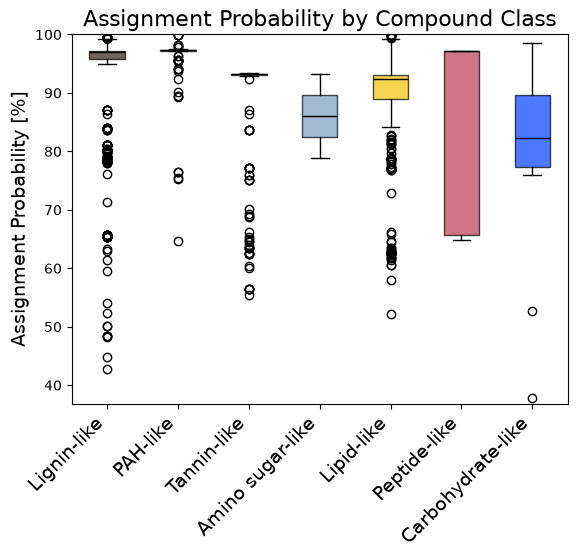

In [18]:
sorted_classes = data_df['compound_class'].unique()[np.argsort([np.median(data_df[data_df['compound_class']==x]['probability']) for x in np.sort(data_df['compound_class'].unique())])]

probabilities_by_class = [data_df[data_df['compound_class']==compound_class]['probability'].to_list() for compound_class in sorted_classes]

fig, ax = plt.subplots()

bplot = ax.boxplot(probabilities_by_class,
                   medianprops = dict(color='k',ls='-'),
                   patch_artist = True,
                   showfliers = True)

for patch, compound_class in zip(bplot['boxes'],sorted_classes):
    patch.set_facecolor(vk_region_colours[compound_class])
    patch.set_alpha(0.7)

    
labels = [f'{x.replace('_',' ').capitalize()}-like' if 'pah' not in x else 'PAH-like' for x in sorted_classes]
ax.set_xticks(np.arange(1,len(labels)+1), labels, rotation=45, ha='right', fontsize=14)

ax.set_ylabel('Assignment Probability [%]',fontsize=14)
ax.set_title('Assignment Probability by Compound Class',fontsize=16)

ax.set_ybound(np.min(data_df['probability'])-1,100)

Finally, we can save the dataframe to a new CSV file with the assignment data.

In [19]:
data_df.to_csv(f'{outputs_folder}/{output_csv_name}',index=None)

The analysis pipeline followed in this notebook can be easily turned into a function which takes the raw pandas dataframe and the prediction model as arguments and outputs a cleaned and assigned dataframe.

In [20]:
def compound_classification(data_df:pd.DataFrame,model:Pipeline|CalibratedClassifierCV,
                            molec_form_column = molecular_formula_column,
                            ratios_needed:list = ['O/C','H/C','N/C'],
                            isotope_pairs:list[list] = [['C','13C'],['H','2H'],['N','15N'],['O','18O'],['S','34S']]) -> pd.DataFrame:

    assert isinstance(model, Pipeline | CalibratedClassifierCV), '`model` must be a `skl.calibration.CalibratedClassifierCV`'
    assert molec_form_column in data_df.columns, '`molec_form_column` must be the column of the `data_df` dataframe containing the assigned empirical formulae.'

    # copy the dataframe into another variable the function will be working on
    # substitute all NaNs with zeros and only select the rows with assigned empirical formulae
    assigned_df = data_df.copy()
    assigned_df = assigned_df[~assigned_df[molec_form_column].isna()]
    assigned_df.fillna(0,inplace=True)

    # check that all necessary stoichiometric ratios are present in the df; add them in if not
    for ratio in ratios_needed:
        if ratio not in assigned_df.columns:
            elements = ratio.split('/')

            numerator = assigned_df[elements[0]]
            denominator = assigned_df[elements[1]]

            # account for isotopes
            for pair in isotope_pairs:
                if elements[0] == pair[0] and pair[1] in assigned_df.columns:
                    numerator += assigned_df[pair[1]]

                if elements[1] == pair[0] and pair[1] in assigned_df.columns:
                    denominator += assigned_df[pair[1]]
            
            assigned_df[ratio] = numerator / denominator
    
    # predict compound classes, their probabilities, and add them as new columns
    predictions = model.predict(assigned_df[ratios_needed].values)
    max_probabilities = np.max(model.predict_proba(assigned_df[ratios_needed].values),axis=1)
    assigned_df['compound_class'] = predictions
    assigned_df['probability'] = max_probabilities

    return assigned_df

In [21]:
data_df2 = pd.read_csv(data_path)
compound_classification(data_df2,model)

,m/z,Calibrated m/z,Calculated m/z,Molecular Formula,C,H,O,S,N,13C,34S,18O,O/C,H/C,N/C,compound_class,probability
0,645.219141,645.218553,645.218366,C45 H30 O3 N2,45.0,30.0,3.0,0.0,2.0,0.0,0.0,0.0,0.066667,0.666667,0.044444,pah,0.974081
1,619.203677,619.203125,619.203229,C30 H36 O14,30.0,36.0,14.0,0.0,0.0,0.0,0.0,0.0,0.466667,1.200000,0.000000,lignin,0.957588
2,617.358234,617.357685,617.357622,C28 H58 O12 S1,28.0,58.0,12.0,1.0,0.0,0.0,0.0,0.0,0.428571,2.071429,0.000000,lipid,0.918628
3,613.541768,613.541223,613.541264,C37 H74 O6,37.0,74.0,6.0,0.0,0.0,0.0,0.0,0.0,0.162162,2.000000,0.000000,lipid,0.961851
4,607.239979,607.239443,607.239615,C30 H40 O13,30.0,40.0,13.0,0.0,0.0,0.0,0.0,0.0,0.433333,1.333333,0.000000,lignin,0.975688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1949,213.076904,213.076827,213.076847,C10 H14 O5,10.0,14.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.400000,0.000000,lignin,0.949730
1950,211.061284,211.061210,211.061197,C10 H12 O5,10.0,12.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.200000,0.000000,lignin,0.957573
1951,211.024872,211.024798,211.024811,C9 H8 O6,9.0,8.0,6.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.888889,0.000000,tannin,0.930281
1952,209.045597,209.045525,209.045547,C10 H10 O5,10.0,10.0,5.0,0.0,0.0,0.0,0.0,0.0,0.500000,1.000000,0.000000,lignin,0.970573


This function can be implemented in your compound class prediction pipeline seamlessly.